In [87]:
!pip install windrose

In [88]:
import os
import pandas as pd
from sqlalchemy import create_engine
from dotenv import load_dotenv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from windrose import WindroseAxes

In [139]:
load_dotenv()
engine = create_engine(os.getenv("SUPABASE_DB_URL"))

query = "SELECT * FROM weather_logs_cleaned ORDER BY timestamp ASC;"
df = pd.read_sql(query, con=engine)
df.head()

,timestamp,temperature_2m,relative_humidity_2m,rain,surface_pressure,precipitation,wind_speed_10m,wind_direction_10m,apparent_temperature,cloud_cover,wind_gusts_10m
0,2026-09-10 00:00,20.02,80.0,0.0,997.72,0.0,21.60,308.0,19.12,100.0,37.08
1,2026-09-10 01:00,19.37,74.0,0.0,998.48,0.0,23.76,316.0,17.43,99.0,44.28
2,2026-09-10 02:00,18.12,73.0,0.0,998.23,0.0,19.44,318.0,16.30,100.0,43.20
3,2026-09-10 03:00,17.82,77.0,0.0,998.90,0.0,18.00,312.0,16.40,46.0,33.12
4,2026-09-10 04:00,17.97,75.0,0.0,999.50,0.0,17.28,303.0,16.56,88.0,33.12


In [26]:
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['minute'] = df['timestamp'].dt.minute
df.head()

,timestamp,temperature_2m,relative_humidity_2m,rain,surface_pressure,precipitation,wind_speed_10m,wind_direction_10m,apparent_temperature,cloud_cover,wind_gusts_10m,date,time,year,month,day,hour,minute
0,2026-09-10 00:00:00,20.02,80.0,0.0,997.72,0.0,21.60,308.0,19.12,100.0,37.08,2026-09-10,00:00:00,2026,9,10,0,0
1,2026-09-10 01:00:00,19.37,74.0,0.0,998.48,0.0,23.76,316.0,17.43,99.0,44.28,2026-09-10,01:00:00,2026,9,10,1,0
2,2026-09-10 02:00:00,18.12,73.0,0.0,998.23,0.0,19.44,318.0,16.30,100.0,43.20,2026-09-10,02:00:00,2026,9,10,2,0
3,2026-09-10 03:00:00,17.82,77.0,0.0,998.90,0.0,18.00,312.0,16.40,46.0,33.12,2026-09-10,03:00:00,2026,9,10,3,0
4,2026-09-10 04:00:00,17.97,75.0,0.0,999.50,0.0,17.28,303.0,16.56,88.0,33.12,2026-09-10,04:00:00,2026,9,10,4,0


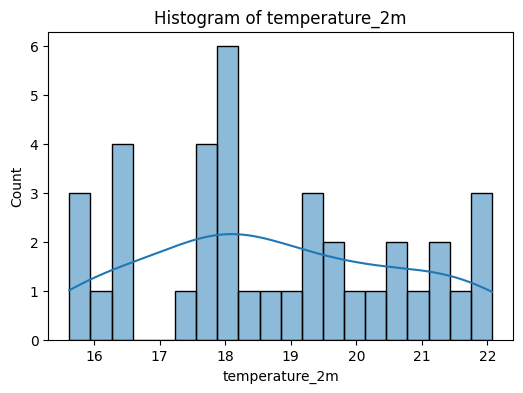

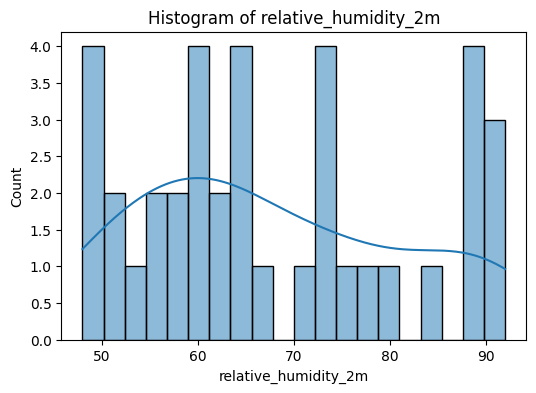

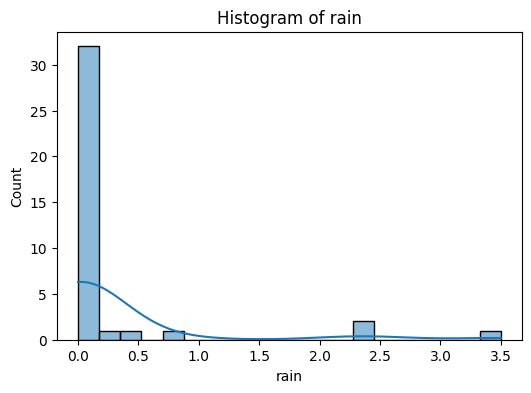

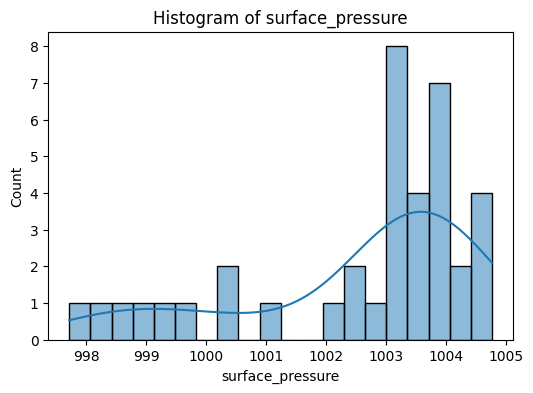

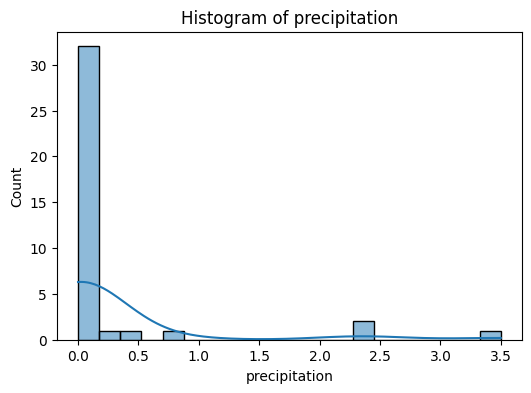

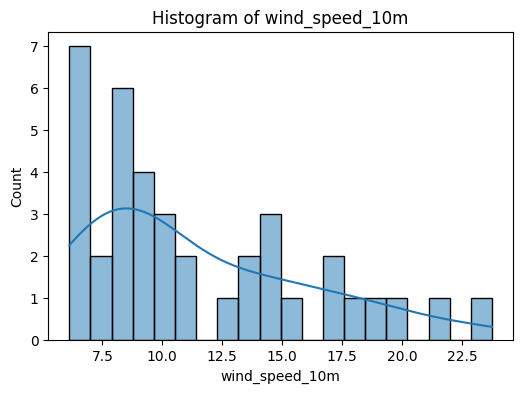

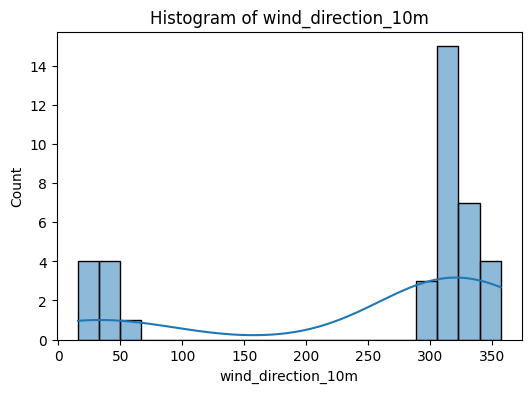

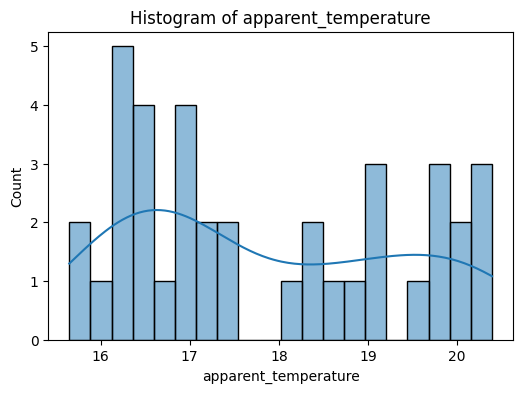

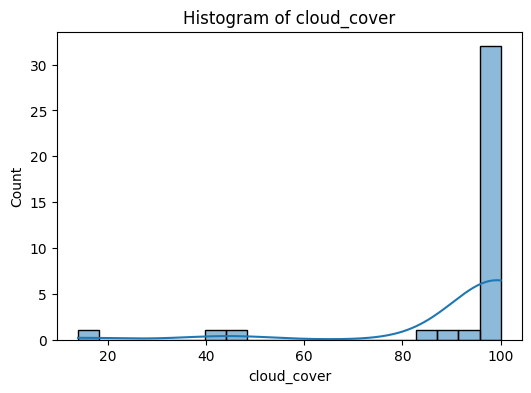

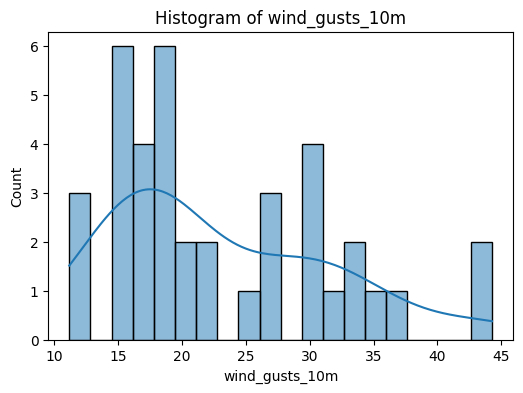

In [15]:
for col in df.columns[1:]:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.title(f"Histogram of {col}")
    plt.show()

# Time series

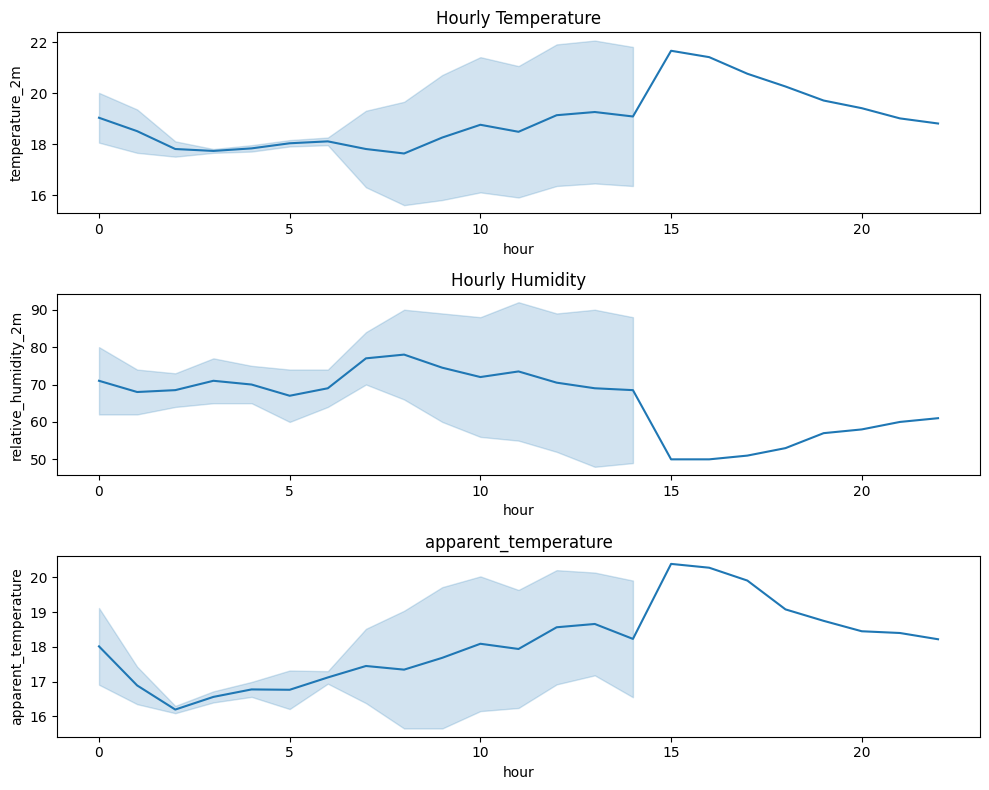

In [76]:
fig, axes = plt.subplots(3, 1, figsize=(10,8))

sns.lineplot(data=df, x="hour", y="temperature_2m", ax=axes[0])
axes[0].set_title("Hourly Temperature")

sns.lineplot(data=df, x="hour", y="relative_humidity_2m", ax=axes[1])
axes[1].set_title("Hourly Humidity")

sns.lineplot(data=df, x="hour", y="apparent_temperature", ax=axes[2])
axes[2].set_title("apparent_temperature")

plt.tight_layout()
plt.show()

C:\Users\heged\AppData\Local\Temp\ipykernel_12536\1626166029.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


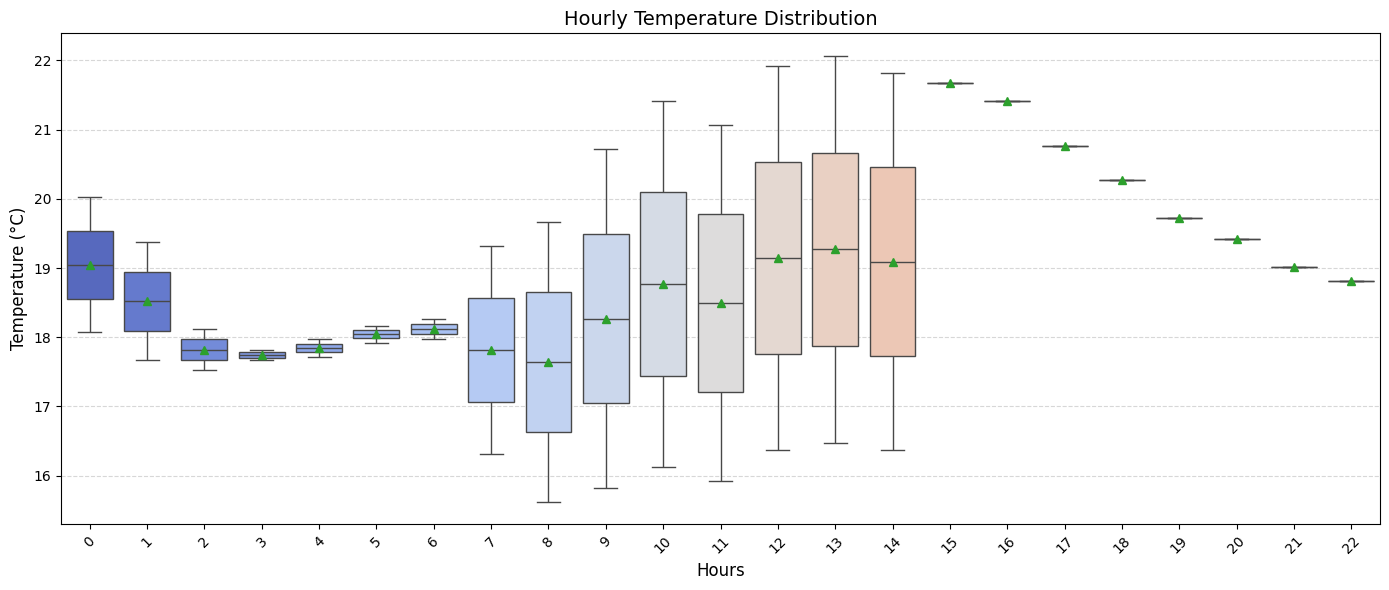

In [118]:
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df,
    x="hour",
    y="temperature_2m",
    palette="coolwarm",
    showmeans=True
)

plt.title('Hourly Temperature Distribution', fontsize=14)
plt.xlabel('Hours', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# Bivariate Analysis

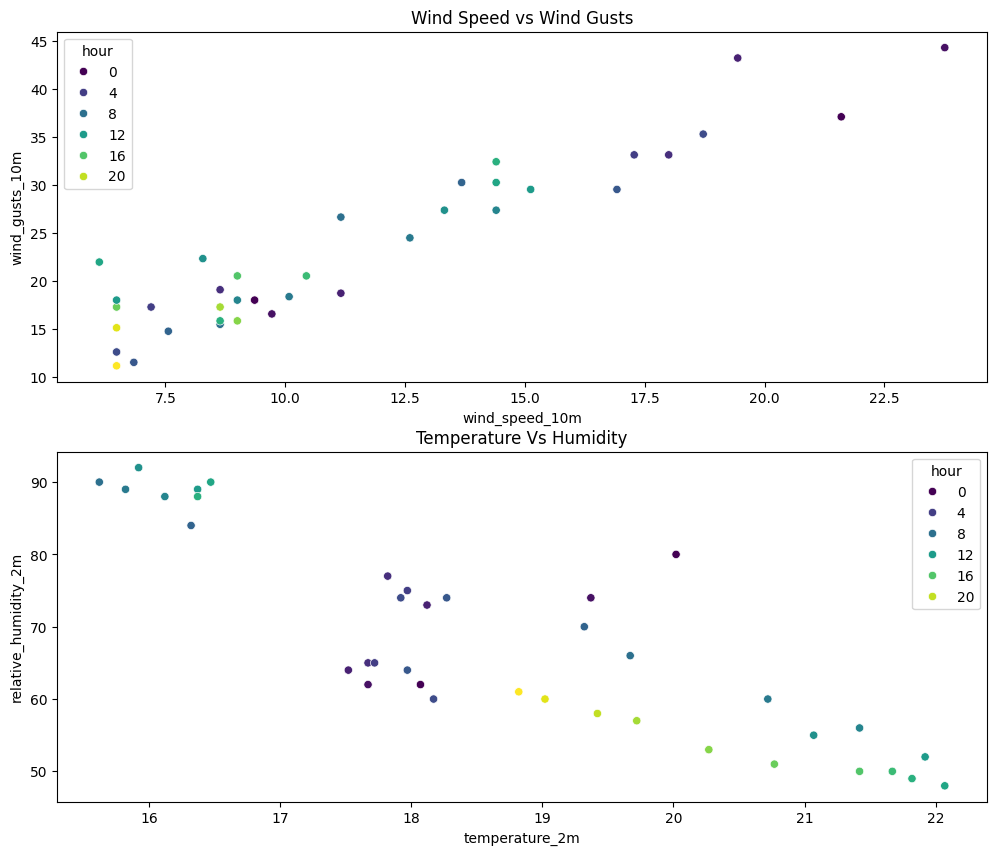

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

In [130]:
fig, axes = plt.subplots(2, 1, figsize=(12,10))
plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="wind_speed_10m",
    y="wind_gusts_10m",
    hue="hour",        # napszak színezés
    palette="viridis",  # színskála
    ax=axes[0]
)
axes[0].set_title("Wind Speed vs Wind Gusts")

plt.figure(figsize=(6,4))
sns.scatterplot(
    data=df,
    x="temperature_2m",
    y="relative_humidity_2m",
    hue="hour",        # napszak színezés
    palette="viridis",
    ax=axes[1]
)
axes[1].set_title("Temperature Vs Humidity")
plt.tight_layout()

plt.show()

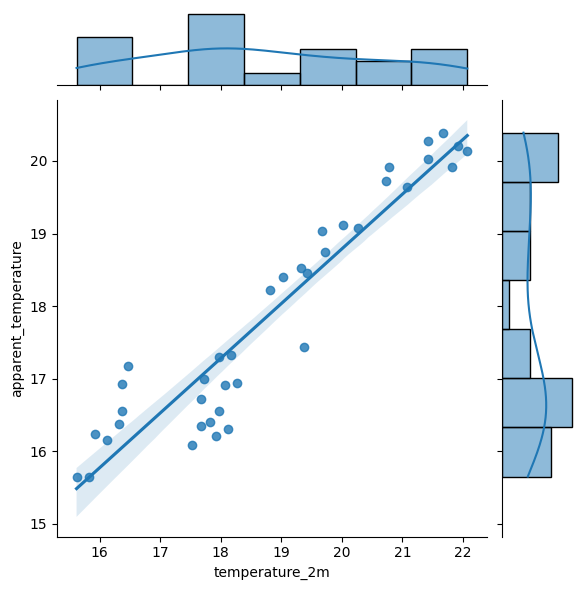

In [137]:
sns.jointplot(data=df,x="temperature_2m",y="apparent_temperature",kind="reg")

plt.show()

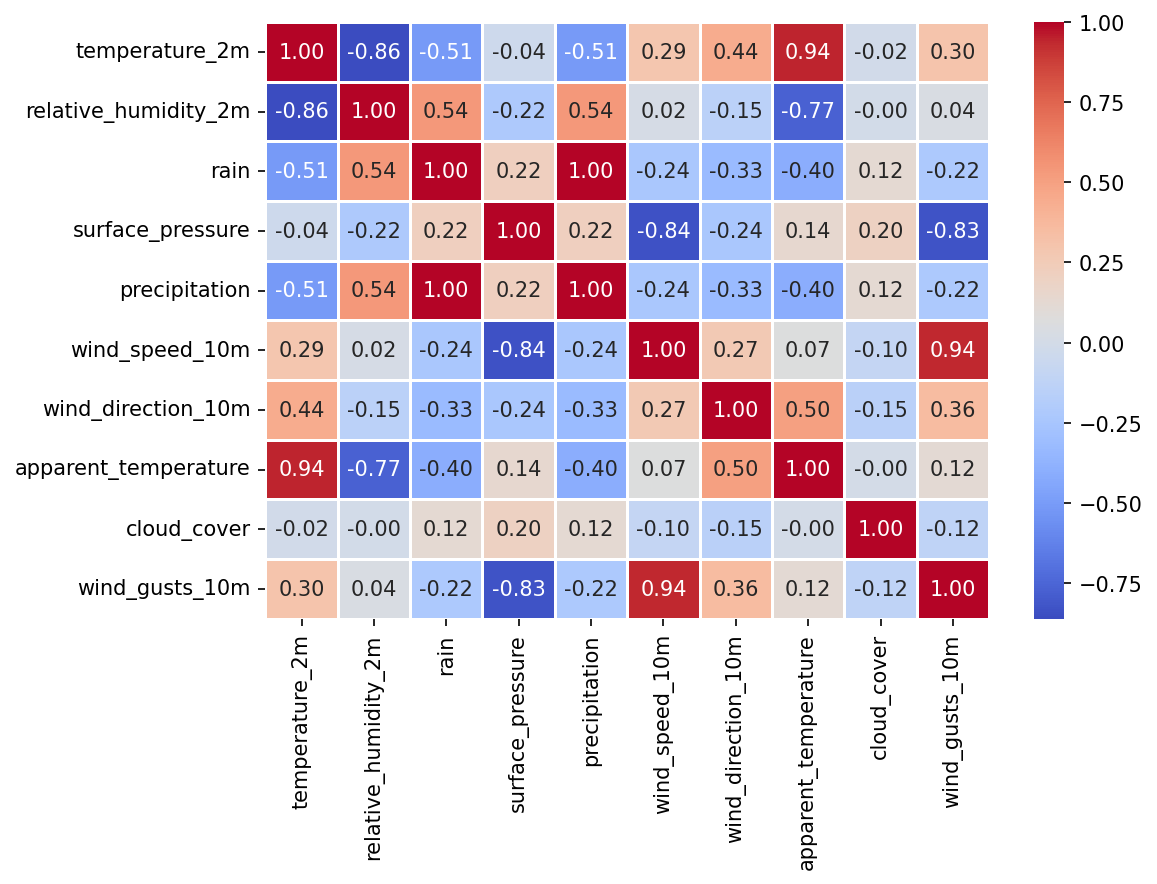

In [141]:
plt.figure(figsize=(8, 6), dpi=150)
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
)
plt.tight_layout()
plt.show()

# Meteorological Analysis

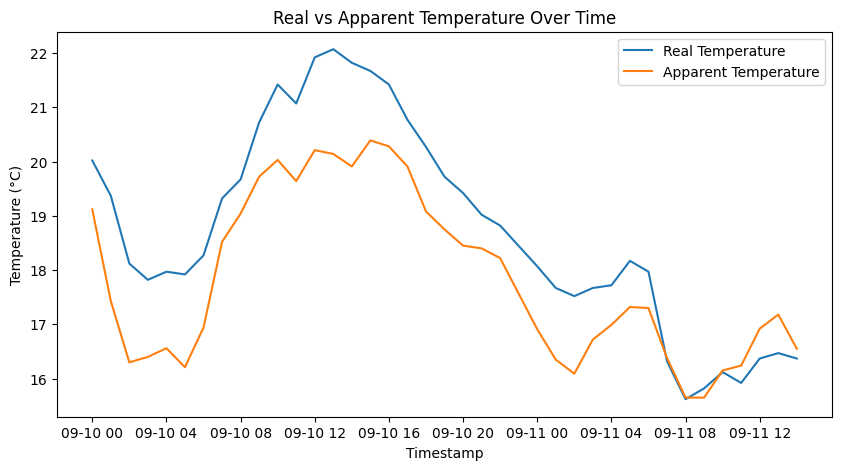

In [86]:
plt.figure(figsize=(10,5))

sns.lineplot(data=df, x="timestamp", y="temperature_2m", label="Real Temperature")
sns.lineplot(data=df, x="timestamp", y="apparent_temperature", label="Apparent Temperature")

plt.title("Real vs Apparent Temperature Over Time")
plt.xlabel("Timestamp")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()

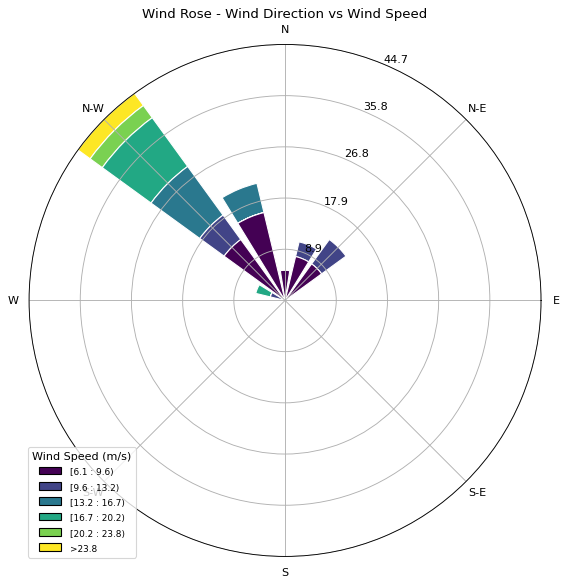

In [89]:
ax = WindroseAxes.from_ax()
ax.bar(
    df['wind_direction_10m'],
    df['wind_speed_10m'],
    normed=True,
    opening=0.8,
    edgecolor='white'
)

ax.set_title("Wind Rose - Wind Direction vs Wind Speed")
ax.set_legend(title="Wind Speed (m/s)")

plt.show()

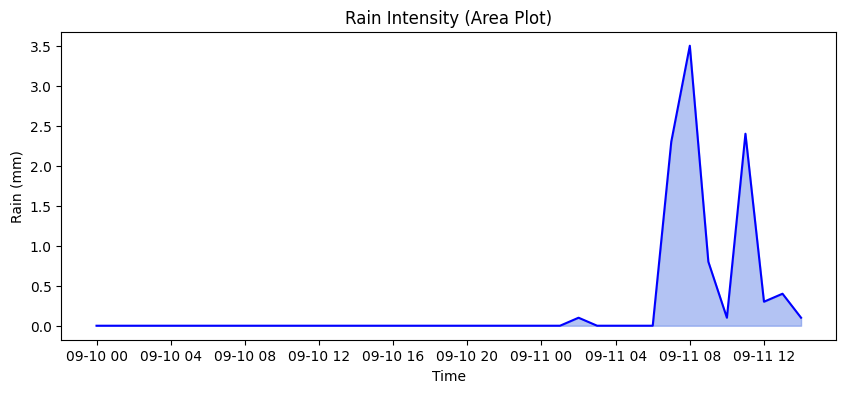

In [90]:
plt.figure(figsize=(10,4))
plt.fill_between(df["timestamp"], df["rain"], alpha=0.4, color="royalblue")
plt.plot(df["timestamp"], df["rain"], color="blue")
plt.title("Rain Intensity (Area Plot)")
plt.xlabel("Time")
plt.ylabel("Rain (mm)")
plt.show()

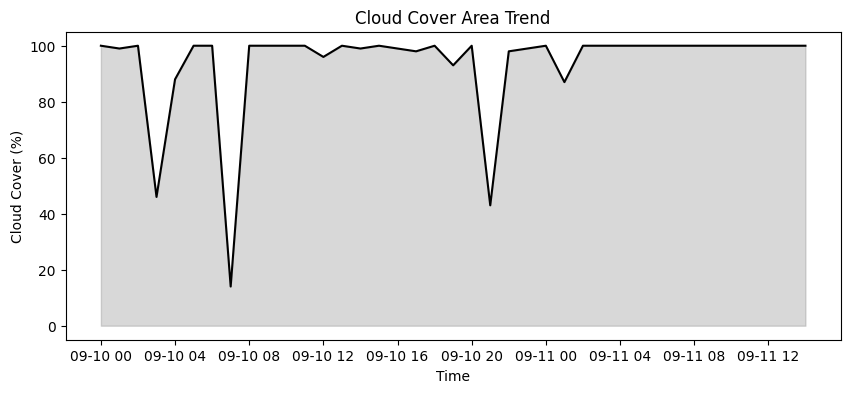

In [97]:
plt.figure(figsize=(10,4))
plt.fill_between(df["timestamp"], df["cloud_cover"], alpha=0.3, color="gray")
plt.plot(df["timestamp"], df["cloud_cover"], color="black")
plt.title("Cloud Cover Area Trend")
plt.xlabel("Time")
plt.ylabel("Cloud Cover (%)")
plt.show()

In [138]:
df.head()

,timestamp,temperature_2m,relative_humidity_2m,rain,surface_pressure,precipitation,wind_speed_10m,wind_direction_10m,apparent_temperature,cloud_cover,wind_gusts_10m,date,time,year,month,day,hour,minute
0,2026-09-10 00:00:00,20.02,80.0,0.0,997.72,0.0,21.60,308.0,19.12,100.0,37.08,2026-09-10,00:00:00,2026,9,10,0,0
1,2026-09-10 01:00:00,19.37,74.0,0.0,998.48,0.0,23.76,316.0,17.43,99.0,44.28,2026-09-10,01:00:00,2026,9,10,1,0
2,2026-09-10 02:00:00,18.12,73.0,0.0,998.23,0.0,19.44,318.0,16.30,100.0,43.20,2026-09-10,02:00:00,2026,9,10,2,0
3,2026-09-10 03:00:00,17.82,77.0,0.0,998.90,0.0,18.00,312.0,16.40,46.0,33.12,2026-09-10,03:00:00,2026,9,10,3,0
4,2026-09-10 04:00:00,17.97,75.0,0.0,999.50,0.0,17.28,303.0,16.56,88.0,33.12,2026-09-10,04:00:00,2026,9,10,4,0
